In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
sales_df = pd.read_csv("Sales Data.csv")
sales_df.head(10)

,Unnamed: 0,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,0,295665,Macbook Pro Laptop,1,1700.00,2019/12/30 0:01,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,1,295666,LG Washing Machine,1,600.00,2019/12/29 7:03,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,2,295667,USB-C Charging Cable,1,11.95,2019/12/12 18:21,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,3,295668,27in FHD Monitor,1,149.99,2019/12/22 15:13,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,4,295669,USB-C Charging Cable,1,11.95,2019/12/18 12:38,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12
5,5,295670,AA Batteries (4-pack),1,3.84,2019/12/31 22:58,"200 Jefferson St, New York City, NY 10001",12,3.84,New York City,22
6,6,295671,USB-C Charging Cable,1,11.95,2019/12/16 15:10,"928 12th St, Portland, OR 97035",12,11.95,Portland,15
7,7,295672,USB-C Charging Cable,2,11.95,2019/12/13 9:29,"813 Hickory St, Dallas, TX 75001",12,23.90,Dallas,9
8,8,295673,Bose SoundSport Headphones,1,99.99,2019/12/15 23:26,"718 Wilson St, Dallas, TX 75001",12,99.99,Dallas,23
9,9,295674,AAA Batteries (4-pack),4,2.99,2019/12/28 11:51,"77 7th St, Dallas, TX 75001",12,11.96,Dallas,11


In [3]:
sales_df.shape

(185950, 11)

In [4]:
sales_df.columns

Index(['Unnamed: 0', 'Order ID', 'Product', 'Quantity Ordered', 'Price Each',
       'Order Date', 'Purchase Address', 'Month', 'Sales', 'City', 'Hour'],
      dtype='object')

In [5]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185950 entries, 0 to 185949
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        185950 non-null  int64  
 1   Order ID          185950 non-null  int64  
 2   Product           185950 non-null  object 
 3   Quantity Ordered  185950 non-null  int64  
 4   Price Each        185950 non-null  float64
 5   Order Date        185950 non-null  object 
 6   Purchase Address  185950 non-null  object 
 7   Month             185950 non-null  int64  
 8   Sales             185950 non-null  float64
 9   City              185950 non-null  object 
 10  Hour              185950 non-null  int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 15.6+ MB


In [6]:
sales_df.describe()

,Unnamed: 0,Order ID,Quantity Ordered,Price Each,Month,Sales,Hour
count,185950.000000,185950.000000,185950.000000,185950.000000,185950.000000,185950.000000,185950.000000
mean,8340.388475,230417.569379,1.124383,184.399735,7.059140,185.490917,14.413305
std,5450.554093,51512.737110,0.442793,332.731330,3.502996,332.919771,5.423416
min,0.000000,141234.000000,1.000000,2.990000,1.000000,2.990000,0.000000
25%,3894.000000,185831.250000,1.000000,11.950000,4.000000,11.950000,11.000000
50%,7786.000000,230367.500000,1.000000,14.950000,7.000000,14.950000,15.000000
75%,11872.000000,275035.750000,1.000000,150.000000,10.000000,150.000000,19.000000
max,25116.000000,319670.000000,9.000000,1700.000000,12.000000,3400.000000,23.000000


In [7]:
sales_df.nunique()

,0
Unnamed: 0,25093
Order ID,178437
Product,19
Quantity Ordered,9
Price Each,17
Order Date,142395
Purchase Address,140787
Month,12
Sales,53
City,9


##Clean Data

In [8]:
# Check missing values
sales_df.isnull().sum()

,0
Unnamed: 0,0
Order ID,0
Product,0
Quantity Ordered,0
Price Each,0
Order Date,0
Purchase Address,0
Month,0
Sales,0
City,0


In [9]:
sales_df = sales_df.drop(columns=["Unnamed: 0"])

In [10]:
sales_df.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,City,Hour
0,295665,Macbook Pro Laptop,1,1700.00,2019/12/30 0:01,"136 Church St, New York City, NY 10001",12,1700.00,New York City,0
1,295666,LG Washing Machine,1,600.00,2019/12/29 7:03,"562 2nd St, New York City, NY 10001",12,600.00,New York City,7
2,295667,USB-C Charging Cable,1,11.95,2019/12/12 18:21,"277 Main St, New York City, NY 10001",12,11.95,New York City,18
3,295668,27in FHD Monitor,1,149.99,2019/12/22 15:13,"410 6th St, San Francisco, CA 94016",12,149.99,San Francisco,15
4,295669,USB-C Charging Cable,1,11.95,2019/12/18 12:38,"43 Hill St, Atlanta, GA 30301",12,11.95,Atlanta,12


In [11]:
sales_df.duplicated().sum()

np.int64(264)

In [12]:
# Remove duplicate rows
sales_df = sales_df.drop_duplicates()

# Check the dataset size
sales_df.shape

(185686, 10)

In [13]:
# Convert Order Date to datetime
sales_df["Order Date"] = pd.to_datetime(sales_df["Order Date"])

In [14]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185686 entries, 0 to 185949
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Order ID          185686 non-null  int64         
 1   Product           185686 non-null  object        
 2   Quantity Ordered  185686 non-null  int64         
 3   Price Each        185686 non-null  float64       
 4   Order Date        185686 non-null  datetime64[ns]
 5   Purchase Address  185686 non-null  object        
 6   Month             185686 non-null  int64         
 7   Sales             185686 non-null  float64       
 8   City              185686 non-null  object        
 9   Hour              185686 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 15.6+ MB


In [15]:
sales_df["Day"] = sales_df["Order Date"].dt.day
sales_df["Weekday"] = sales_df["Order Date"].dt.day_name()

## Q1: Which month generates the highest revenue?

In [16]:
monthly_sales = sales_df.groupby("Month")["Sales"].sum().sort_index()

monthly_sales

,Sales
Month,
1,1821413.16
2,2200078.08
3,2804973.35
4,3389217.98
5,3150616.23
6,2576280.15
7,2646461.32
8,2241083.37
9,2094465.69


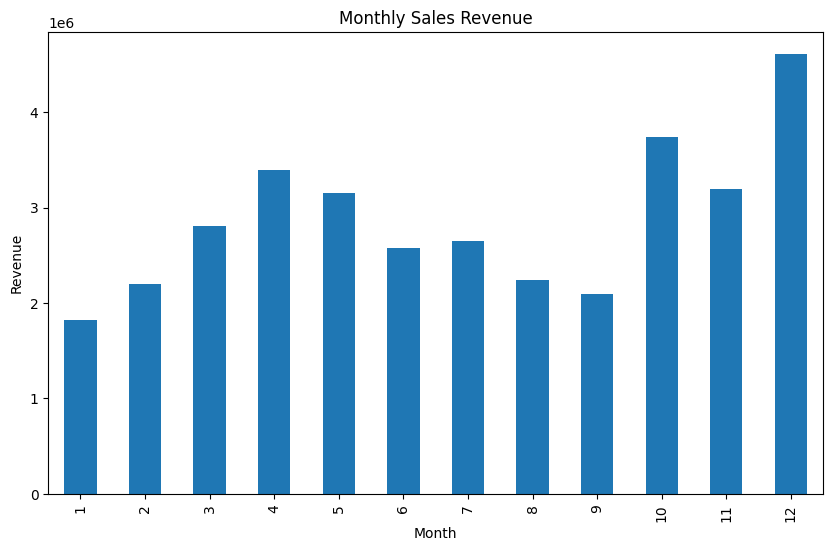

In [17]:
monthly_sales.plot(kind="bar", figsize=(10,6))

plt.title("Monthly Sales Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

###December generated the highest sales revenue, indicating that holiday shopping (Xmas) significantly increased customer purchases.

## Q2: Which city contributes the most sales?

In [18]:
city_sales = sales_df.groupby("City")["Sales"].sum().sort_values(ascending=False)

city_sales

,Sales
City,
San Francisco,8254743.55
Los Angeles,5448304.28
New York City,4661867.14
Boston,3658627.65
Atlanta,2794199.07
Dallas,2765373.96
Seattle,2745046.02
Portland,2319331.94
Austin,1818044.33


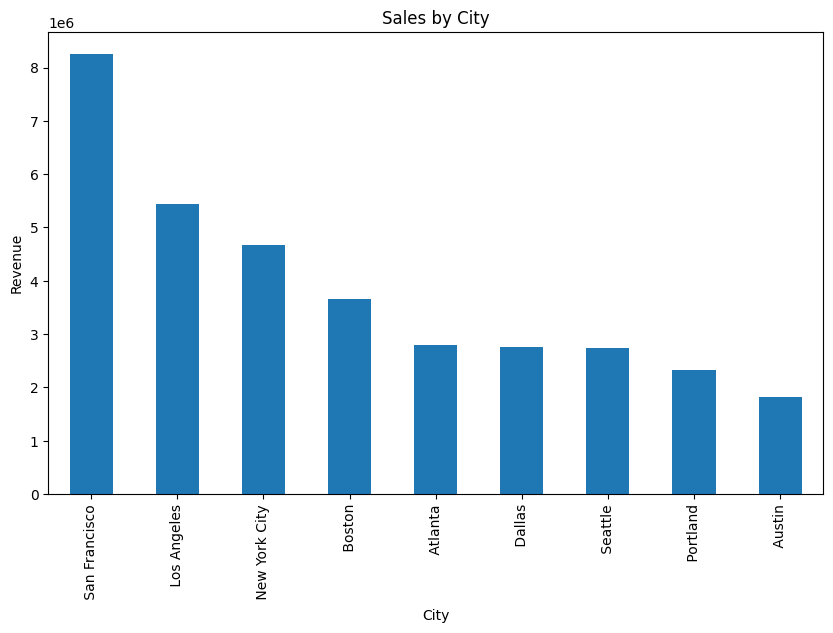

In [19]:
city_sales.plot(kind="bar", figsize=(10,6))

plt.title("Sales by City")
plt.ylabel("Revenue")

plt.show()

###San Francisco generated the highest sales revenue among all cities, followed by Los Angeles and New York City. This suggests that larger metropolitan areas contribute a greater proportion of total sales, likely due to higher population density and stronger consumer demand.

## Q3： Which products have the highest quantity sold and revenue contribution?

In [20]:
product_quantity = sales_df.groupby("Product")["Quantity Ordered"].sum().sort_values(ascending=False)

product_quantity


,Quantity Ordered
Product,
AAA Batteries (4-pack),30986
AA Batteries (4-pack),27615
USB-C Charging Cable,23931
Lightning Charging Cable,23169
Wired Headphones,20524
Apple Airpods Headphones,15637
Bose SoundSport Headphones,13430
27in FHD Monitor,7541
iPhone,6847


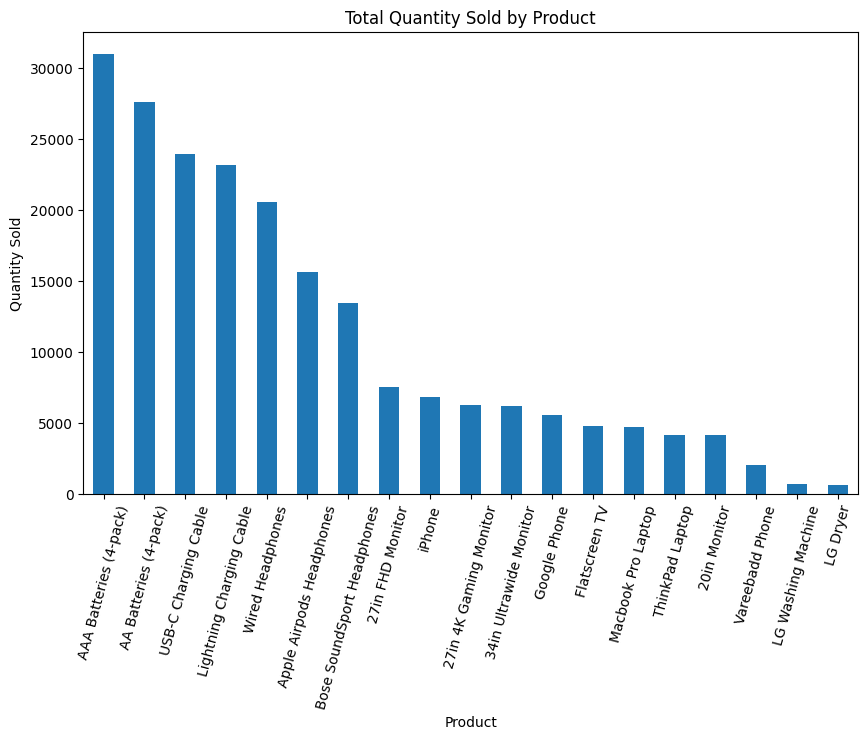

In [21]:
plt.figure(figsize=(10,6))

product_quantity.plot(kind="bar")

plt.title("Total Quantity Sold by Product")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=75)

plt.show()

### AAA Batteries (4-pack) recorded the highest quantity sold, followed by AA Batteries (4-pack), USB-C Charging Cable, and Lightning Charging Cable. These products are inexpensive accessories that customers purchase frequently, resulting in high sales volume.

In [22]:
product_sales = sales_df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

product_sales

,Sales
Product,
Macbook Pro Laptop,8032500.00
iPhone,4792900.00
ThinkPad Laptop,4127958.72
Google Phone,3317400.00
27in 4K Gaming Monitor,2433147.61
34in Ultrawide Monitor,2352898.08
Apple Airpods Headphones,2345550.00
Flatscreen TV,1443900.00
Bose SoundSport Headphones,1342865.70


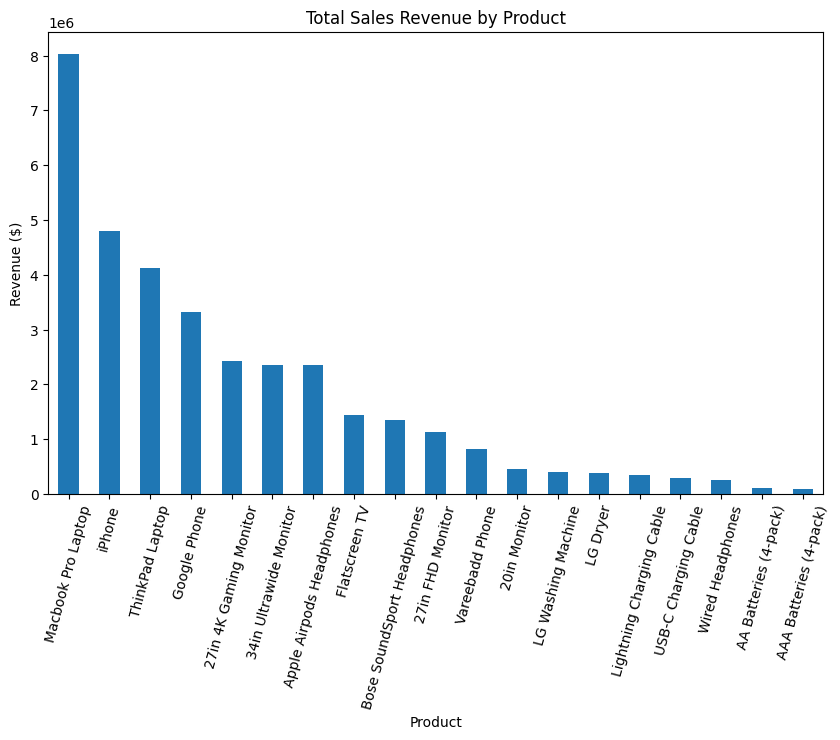

In [23]:
plt.figure(figsize=(10,6))

product_sales.plot(kind="bar")

plt.title("Total Sales Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=75)

plt.show()

### MacBook Pro Laptop generated the highest total revenue, followed by iPhone and ThinkPad Laptop. Although these products were sold in lower quantities than accessories, their high selling prices resulted in significantly greater revenue contributions.

### Batteries have the highest sales quantity but contribute relatively little revenue because of their low unit prices. In contrast, laptops generate much higher revenue despite lower sales volumes due to their premium pricing.

### The comparison shows that high sales volume does not necessarily result in the highest revenue. Low-priced products such as batteries and charging cables are sold frequently but contribute relatively little revenue. Premium products such as laptops generate much higher revenue despite lower sales quantities because of their higher unit prices.

## Q4： What time of day has the highest order activity?

In [24]:
hourly_orders = sales_df.groupby("Hour").size()

hourly_orders

,0
Hour,
0,3902
1,2347
2,1242
3,830
4,852
5,1320
6,2481
7,4002
8,6252


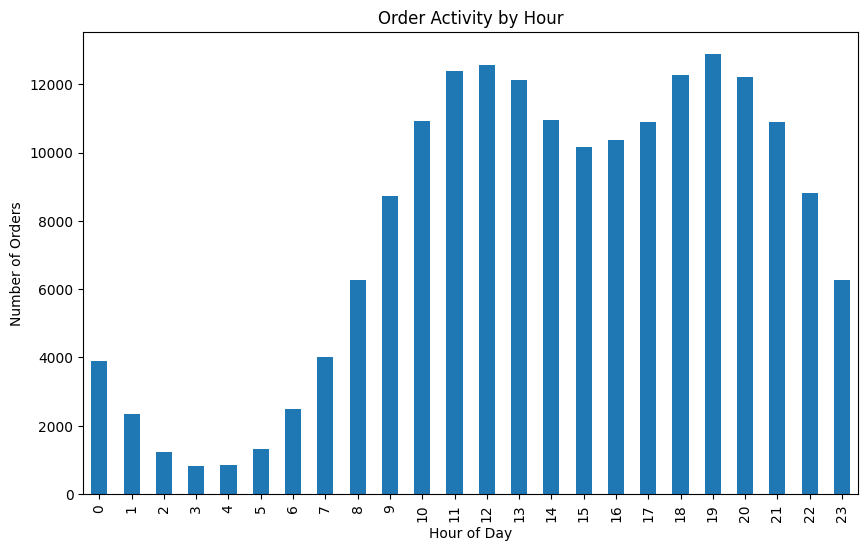

In [25]:
plt.figure(figsize=(10,6))

hourly_orders.plot(kind="bar")

plt.title("Order Activity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.show()

### The bar chart shows that order activity gradually increased throughout the day and reached its highest level at 19:00 (7 PM). Order volumes remained relatively high between 11:00 AM and 9:00 PM, while very few orders were placed during the early morning hours (2:00 AM to 5:00 AM). This suggests that customers were more likely to shop during the afternoon and evening, possibly after work or school.

## Q5： Are expensive products sold less frequently?

In [26]:
price_quantity = sales_df.groupby("Product").agg({"Price Each": "mean", "Quantity Ordered": "sum"})

price_quantity

,Price Each,Quantity Ordered
Product,,
20in Monitor,109.99,4126
27in 4K Gaming Monitor,389.99,6239
27in FHD Monitor,149.99,7541
34in Ultrawide Monitor,379.99,6192
AA Batteries (4-pack),3.84,27615
AAA Batteries (4-pack),2.99,30986
Apple Airpods Headphones,150.00,15637
Bose SoundSport Headphones,99.99,13430
Flatscreen TV,300.00,4813


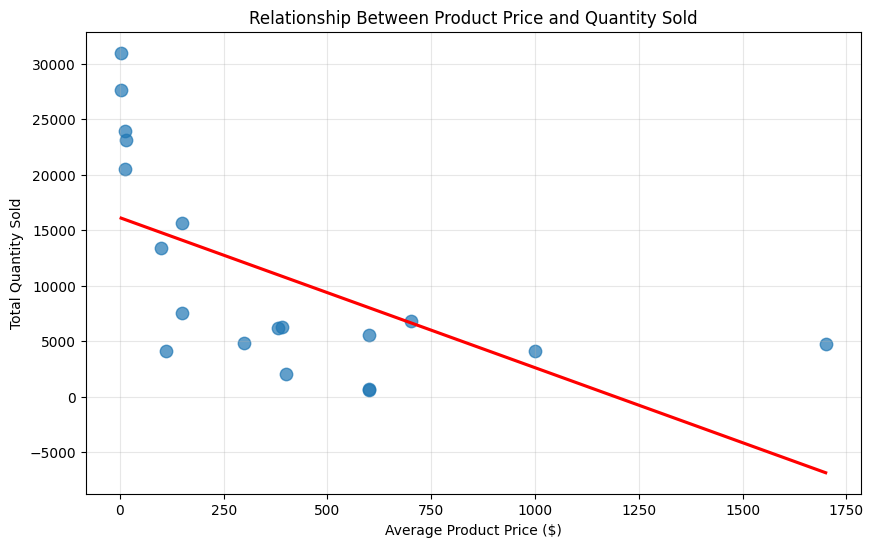

In [27]:

plt.figure(figsize=(10,6))

sns.regplot(
    data=price_quantity,
    x="Price Each",
    y="Quantity Ordered",
    ci=None,
    scatter_kws={"s":80, "alpha":0.7},
    line_kws={"color":"red"}
)

plt.title("Relationship Between Product Price and Quantity Sold")
plt.xlabel("Average Product Price ($)")
plt.ylabel("Total Quantity Sold")

plt.grid(alpha=0.3)

plt.show()

In [28]:
correlation = price_quantity["Price Each"].corr(price_quantity["Quantity Ordered"], method="pearson")

print("Correlation coefficient:", round(correlation, 3))

Correlation coefficient: -0.601


### The scatter plot shows a moderate negative relationship between product price and total quantity sold. The correlation coefficient is -0.601, indicating that products with higher prices generally have lower sales volumes.

### Low-priced products such as AAA Batteries, AA Batteries and charging cables recorded the highest quantities sold, while expensive products tended to sell fewer units. However, some high-priced products, such as the MacBook Pro Laptop, still achieved relatively strong sales, indicating that factors other than price also influence customer purchasing behaviour.

### Overall, the analysis suggests that more expensive products are generally sold less frequently, although the relationship is not perfect.

## Q6： Which products are frequently purchased together?

In [ ]:
basket = sales_df.groupby("Order ID")["Product"].apply(list)

basket.head()

,Product
Order ID,
141234,[iPhone]
141235,[Lightning Charging Cable]
141236,[Wired Headphones]
141237,[27in FHD Monitor]
141238,[Wired Headphones]


In [ ]:
basket = basket[basket.apply(len) > 1]

basket.head()

,Product
Order ID,
141275,"[USB-C Charging Cable, Wired Headphones]"
141290,"[Apple Airpods Headphones, AA Batteries (4-pack)]"
141365,"[Vareebadd Phone, Wired Headphones]"
141384,"[Google Phone, USB-C Charging Cable]"
141450,"[Google Phone, Bose SoundSport Headphones]"


In [ ]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

print("mlxtend imported successfully")

mlxtend imported successfully


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
te = TransactionEncoder()

te_array = te.fit(basket).transform(basket)

basket_df = pd.DataFrame(
    te_array,
    columns=te.columns_
)

basket_df.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,20in Monitor,27in 4K Gaming Monitor,27in FHD Monitor,34in Ultrawide Monitor,AA Batteries (4-pack),AAA Batteries (4-pack),Apple Airpods Headphones,Bose SoundSport Headphones,Flatscreen TV,Google Phone,LG Dryer,LG Washing Machine,Lightning Charging Cable,Macbook Pro Laptop,ThinkPad Laptop,USB-C Charging Cable,Vareebadd Phone,Wired Headphones,iPhone
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False
3,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False
4,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

###Market Basket Analysis using Apriori Algorithm

###This analysis identifies products that are frequently purchased together using the Apriori algorithm and association rules.

In [ ]:
frequent_items = apriori(
    basket_df,
    min_support=0.02,
    use_colnames=True
)

frequent_items = frequent_items.sort_values(
    "support",
    ascending=False
)

frequent_items.head(20)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets
13,0.293793,(USB-C Charging Cable)
16,0.270970,(iPhone)
10,0.251199,(Lightning Charging Cable)
9,0.237389,(Google Phone)
15,0.233610,(Wired Headphones)
21,0.146969,"(iPhone, Lightning Charging Cable)"
19,0.144934,"(USB-C Charging Cable, Google Phone)"
6,0.134613,(Apple Airpods Headphones)
7,0.111353,(Bose SoundSport Headphones)
5,0.107283,(AAA Batteries (4-pack))


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
rules = association_rules(
    frequent_items,
    metric="lift",
    min_threshold=1
)

rules.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(iPhone),(Lightning Charging Cable),0.270970,0.251199,0.146969,0.542382,2.159170,1.0,0.078902,1.636301,0.736401,0.391709,0.388865,0.563726
1,(Lightning Charging Cable),(iPhone),0.251199,0.270970,0.146969,0.585069,2.159170,1.0,0.078902,1.756994,0.716959,0.391709,0.430846,0.563726
2,(USB-C Charging Cable),(Google Phone),0.293793,0.237389,0.144934,0.493320,2.078107,1.0,0.075191,1.505114,0.734618,0.375235,0.335598,0.551926
3,(Google Phone),(USB-C Charging Cable),0.237389,0.293793,0.144934,0.610533,2.078107,1.0,0.075191,1.813265,0.680285,0.375235,0.448509,0.551926
4,(iPhone),(Wired Headphones),0.270970,0.233610,0.067161,0.247854,1.060976,1.0,0.003860,1.018939,0.078833,0.153539,0.018587,0.267673


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
rules = rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
]

rules.head(10)

###The association rules show strong purchasing relationships between several products. For example, customers who purchased an iPhone were also likely to purchase a Lightning Charging Cable (Lift = 2.16). Similarly, Google Phone purchases were strongly associated with USB-C Charging Cable purchases (Lift = 2.08). These findings can help retailers improve cross-selling strategies and product recommendations.

##Q7： Can machine learning models predict sales revenue accurately?

###Machine learning models were developed to predict sales revenue based on product information, pricing, time, and location variables. Two regression algorithms were implemented and compared:
- Linear Regression
- Random Forest Regression

###The dataset was divided into training and testing sets to evaluate prediction performance.

###Before training the models, the categorical variables (Product and City) were converted into numerical values using Label Encoding. The dataset was then divided into training and testing sets using an 80:20 ratio. The Sales column was selected as the target variable.

In [29]:
sales_df["Order Date"] = pd.to_datetime(sales_df["Order Date"])

In [30]:
sales_df["Day"] = sales_df["Order Date"].dt.day

sales_df["Weekday"] = sales_df["Order Date"].dt.weekday

In [31]:
sales_ml = pd.get_dummies(
    sales_df,
    columns=["Product", "City"],
    drop_first=True
)

sales_ml.head()

,Order ID,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Sales,Hour,Day,Weekday,...,Product_Wired Headphones,Product_iPhone,City_ Austin,City_ Boston,City_ Dallas,City_ Los Angeles,City_ New York City,City_ Portland,City_ San Francisco,City_ Seattle
0,295665,1,1700.00,2019-12-30 00:01:00,"136 Church St, New York City, NY 10001",12,1700.00,0,30,0,...,False,False,False,False,False,False,True,False,False,False
1,295666,1,600.00,2019-12-29 07:03:00,"562 2nd St, New York City, NY 10001",12,600.00,7,29,6,...,False,False,False,False,False,False,True,False,False,False
2,295667,1,11.95,2019-12-12 18:21:00,"277 Main St, New York City, NY 10001",12,11.95,18,12,3,...,False,False,False,False,False,False,True,False,False,False
3,295668,1,149.99,2019-12-22 15:13:00,"410 6th St, San Francisco, CA 94016",12,149.99,15,22,6,...,False,False,False,False,False,False,False,False,True,False
4,295669,1,11.95,2019-12-18 12:38:00,"43 Hill St, Atlanta, GA 30301",12,11.95,12,18,2,...,False,False,False,False,False,False,False,False,False,False


In [32]:
X = sales_ml.drop(columns=["Sales", "Order ID", "Order Date", "Purchase Address"])

y = sales_ml["Sales"]

X.head()

,Quantity Ordered,Price Each,Month,Hour,Day,Weekday,Product_27in 4K Gaming Monitor,Product_27in FHD Monitor,Product_34in Ultrawide Monitor,Product_AA Batteries (4-pack),...,Product_Wired Headphones,Product_iPhone,City_ Austin,City_ Boston,City_ Dallas,City_ Los Angeles,City_ New York City,City_ Portland,City_ San Francisco,City_ Seattle
0,1,1700.00,12,0,30,0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,1,600.00,12,7,29,6,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,1,11.95,12,18,12,3,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,1,149.99,12,15,22,6,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
4,1,11.95,12,12,18,2,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [33]:
X.shape

(185686, 32)

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (129980, 32)
Testing set: (55706, 32)


#### Model 1: Linear Regression

###Linear Regression was used as the baseline regression model. It assumes a linear relationship between the independent variables and the target variable (Sales). The model was trained using the training dataset and evaluated using the testing dataset.

In [35]:
#Model 1：Linear Regression

In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

In [38]:
#Train the dataset
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [39]:
#predict
lr_pred = lr_model.predict(X_test)

In [40]:
lr_r2 = r2_score(y_test, lr_pred)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print("Linear Regression")
print("R2 Score:", round(lr_r2, 4))
print("RMSE:", round(lr_rmse, 4))

Linear Regression
R2 Score: 0.9983
RMSE: 13.6568


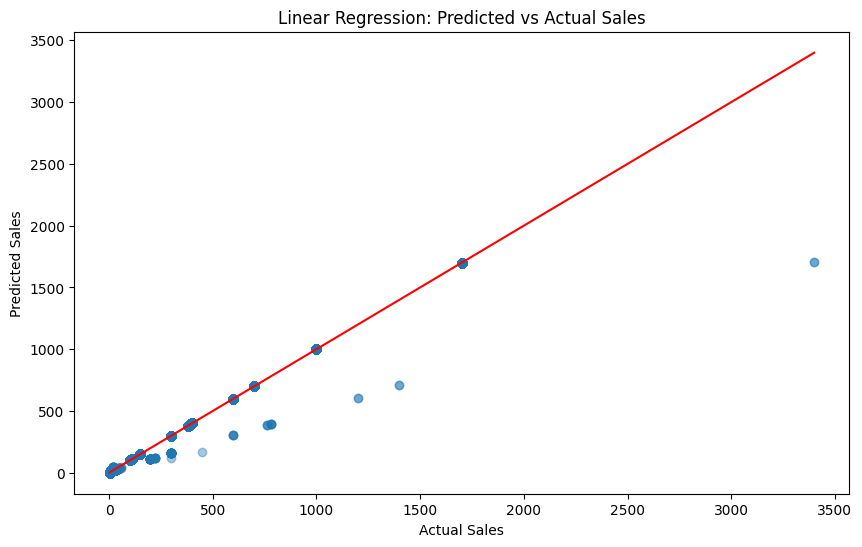

In [41]:
plt.figure(figsize=(10,6))

plt.scatter(y_test, lr_pred, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Linear Regression: Predicted vs Actual Sales")

plt.show()

####The Linear Regression model achieved a high prediction accuracy. The scatter plot compares the predicted sales values with the actual sales values. Most observations are located close to the diagonal reference line, indicating good prediction performance.

R2 Score： 0.9983
RMSE：13.6568

###Random Forest Regression is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy. Compared with Linear Regression, Random Forest can better capture nonlinear relationships in the data.

In [ ]:
#Model 2:Random Forest

In [42]:
from sklearn.ensemble import RandomForestRegressor

In [45]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [46]:
rf_pred = rf_model.predict(X_test)

In [47]:
rf_r2 = r2_score(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest")
print("R2 Score:", round(rf_r2, 4))
print("RMSE:", round(rf_rmse, 4))

Random Forest
R2 Score: 1.0
RMSE: 1.3861


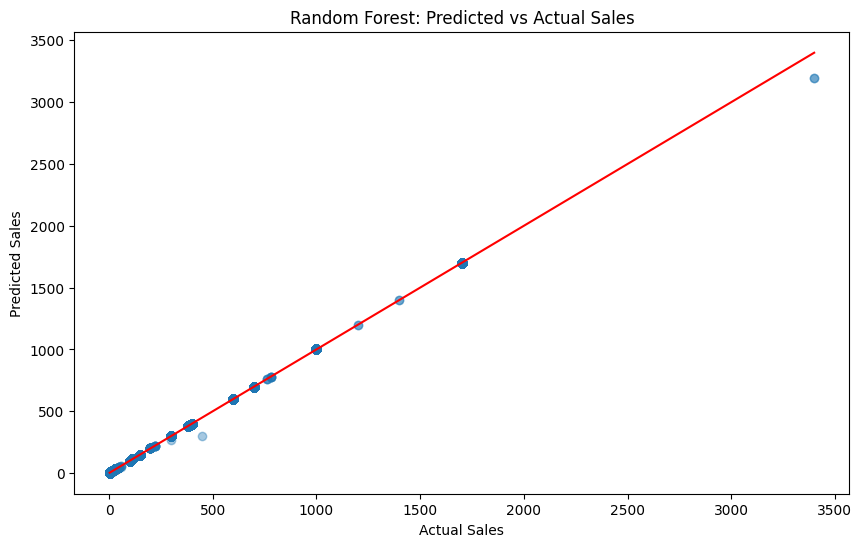

In [48]:
plt.figure(figsize=(10,6))

plt.scatter(y_test, rf_pred, alpha=0.4)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Random Forest: Predicted vs Actual Sales")

plt.show()

###The Random Forest model was evaluated using the same testing dataset. The predicted values are compared with the actual sales values. Most points lie almost exactly on the reference line, indicating excellent prediction performance.

*   R2 Score:1.0
*   RMSE: 1.3861

In [49]:
comparison = pd.DataFrame(
    {
        "Model": ["Linear Regression", "Random Forest"],
        "R² Score": [lr_r2, rf_r2],
        "RMSE": [lr_rmse, rf_rmse]
    }
)

comparison

,Model,R² Score,RMSE
0,Linear Regression,0.998298,13.656791
1,Random Forest,0.999982,1.386122


###The Linear Regression model achieved an R² score of 0.9983 and an RMSE of 13.66, indicating excellent prediction accuracy. Although a few high-value transactions showed larger prediction errors, most predicted values closely followed the actual sales values.

###The Random Forest model further improved prediction performance, achieving an R² score of 1.0000 and an RMSE of 1.39. The predicted values almost completely overlapped with the actual values, demonstrating extremely high predictive accuracy on the testing dataset.

##Q8:Which features are most important in predicting sales?

###Feature importance was extracted from the Random Forest model to identify which variables contribute most to predicting sales revenue.

###The Random Forest model provides an importance score for each feature. Features with higher importance have a greater influence on the prediction of sales revenue.

In [50]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
1,Price Each,8.520905e-01
18,Product_Macbook Pro Laptop,1.347500e-01
19,Product_ThinkPad Laptop,1.020632e-02
0,Quantity Ordered,1.535888e-03
23,Product_iPhone,7.323292e-04
13,Product_Flatscreen TV,6.610813e-04
12,Product_Bose SoundSport Headphones,1.515852e-05
21,Product_Vareebadd Phone,3.381525e-06
17,Product_Lightning Charging Cable,2.441608e-06
6,Product_27in 4K Gaming Monitor,2.105746e-06


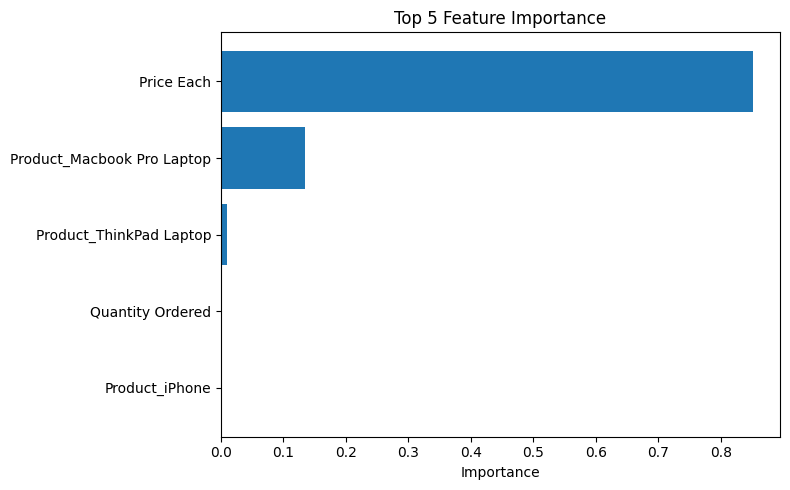

In [52]:
top_features = feature_importance.head(5)

plt.figure(figsize=(8,5))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.title("Top 5 Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

###The feature importance results show that "Price Each" is the most influential feature, with an importance score of approximately **0.85**. This indicates that product price plays the most important role in predicting sales revenue.

###The product categories **MacBook Pro Laptop** and **ThinkPad Laptop** also contribute to the prediction, although their importance is much lower than product price.

###Other variables, including **Quantity Ordered**, **Month**, **Hour**, **Weekday**, and **City**, have relatively low importance, suggesting that they provide limited additional information for predicting sales in this dataset.

###Overall, the Random Forest model relies primarily on product price when making sales predictions.

### Practical Implications

###The results suggest that pricing is the key factor influencing sales prediction. Businesses can use pricing information to improve revenue forecasting and pricing strategies. Although product categories provide some additional predictive value, time-related and location-related variables have relatively little impact in this dataset.